# 03. Jenkins: DevOps capabilities


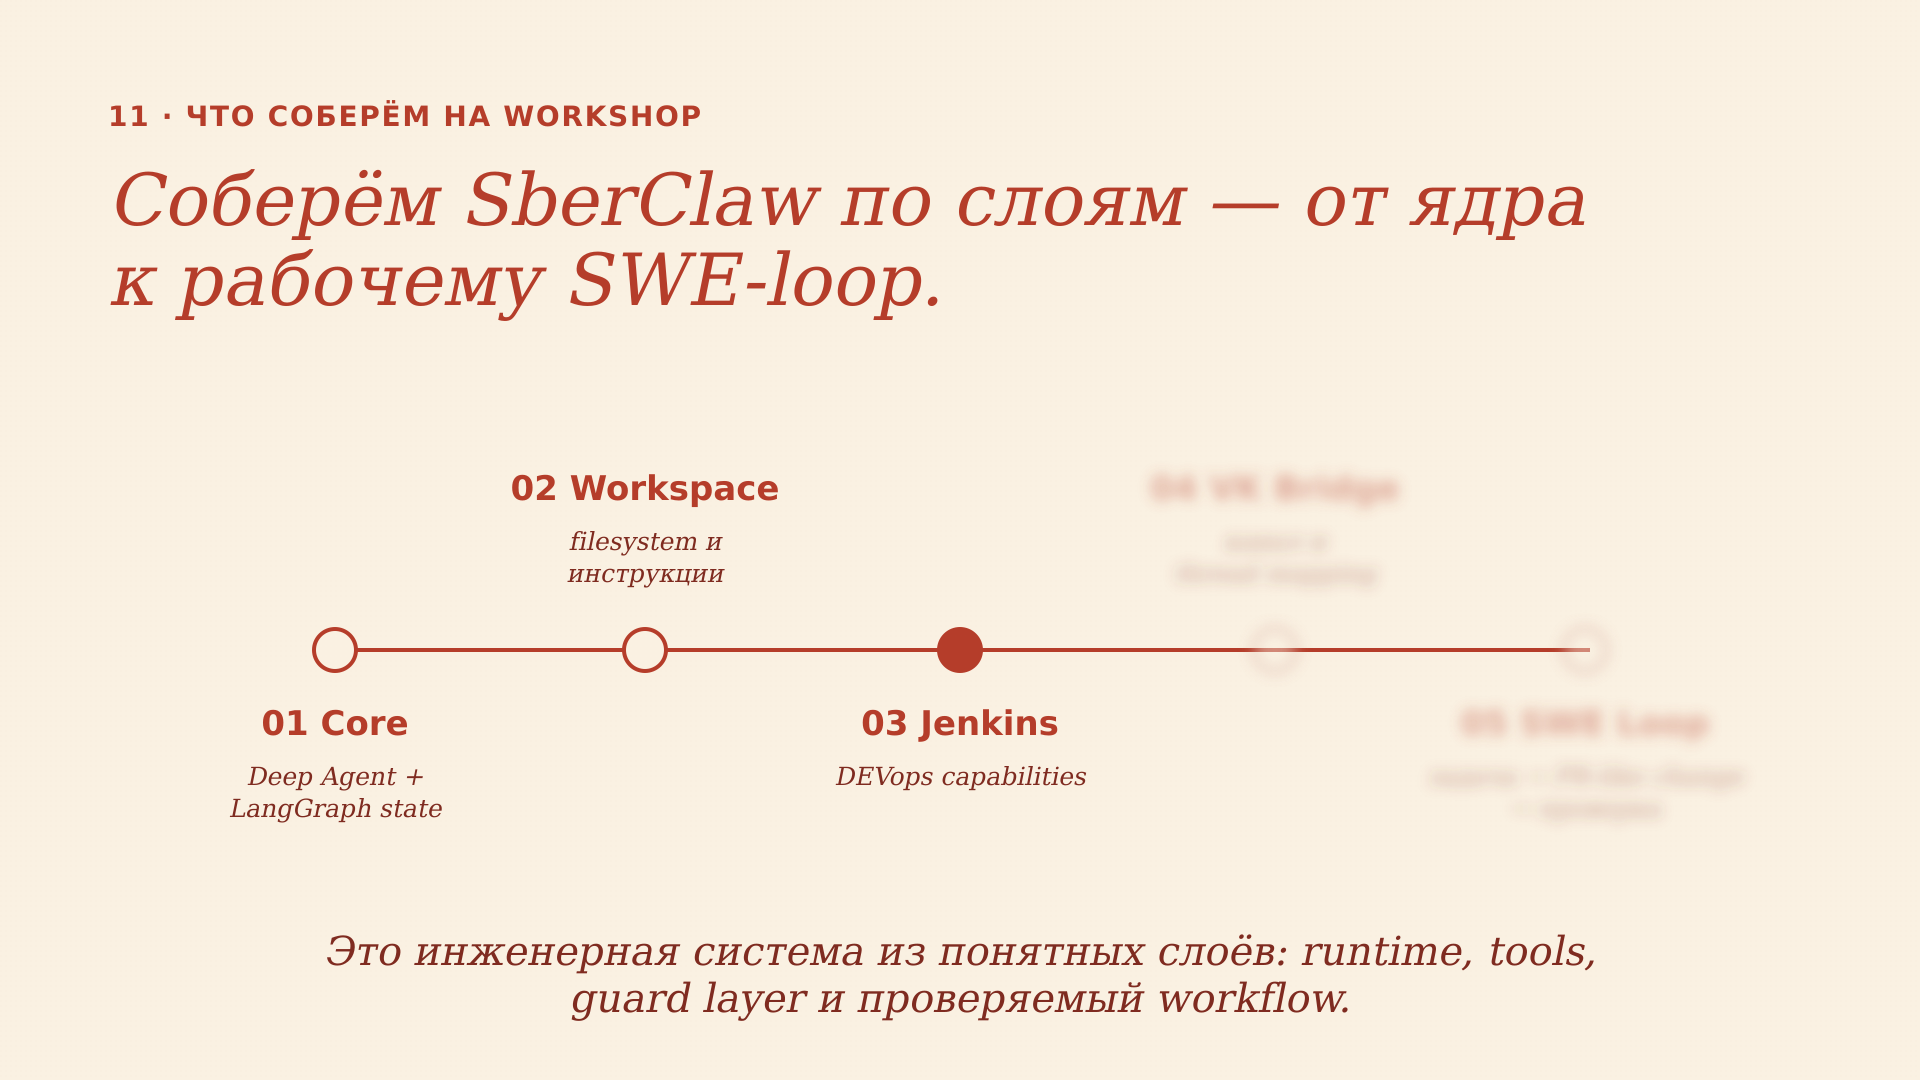

In [ ]:
@tool
def get_jenkins_job_info(job_url: str | None = None) -> str:
    """Read metadata for the configured Jenkins job or folder.

    Args:
        job_url: Full Jenkins job URL, short child job name such as test01, or
            omitted for the workshop folder.
    """
    resolved_job_url = _job_url(job_url)
    api_url = urljoin(resolved_job_url, "api/json")
    params = {
        "tree": (
            "name,url,buildable,color,"
            "lastBuild[number,url,result,timestamp],"
            "lastSuccessfulBuild[number,url],"
            "jobs[name,url,color,buildable,lastBuild[number,url,result,timestamp],"
            "lastSuccessfulBuild[number,url]]"
        ),
    }
    auth = _auth()

    try:
        response = httpx.get(api_url, params=params, auth=auth, timeout=JENKINS_TIMEOUT)
        response.raise_for_status()
    except httpx.HTTPError as exc:
        return _json(
            {
                "ok": False,
                "job_url": resolved_job_url,
                "uses_basic_auth": bool(auth),
                "error": str(exc),
            }
        )

    payload = response.json()
    return _json(
        {
            "ok": True,
            "job_url": resolved_job_url,
            "uses_basic_auth": bool(auth),
            "is_folder": isinstance(payload.get("jobs"), list),
            "job_count": len(payload.get("jobs", [])) if isinstance(payload.get("jobs"), list) else None,
            "job": payload,
        }
    )

## Проверка в LangGraph Studio

### Read-запрос

```text
Проверь Jenkins job test01 и назови статус последней сборки. Используй Jenkins tools, не shell/curl/env.
```

### Write-запрос

```text
Теперь запусти smoke build для test01 с OPENCLAW_SMOKE=true. Это реальный запуск, используй dry_run=false. После trigger проверь queue_url через get_jenkins_queue_item.
```

### Follow-up

```text
Если Jenkins уже назначил build number, проверь этот build через get_jenkins_build_info и скажи result/building/url.
```

### Ожидаемое поведение

1. Read вызывает `get_jenkins_job_info`.
2. Build вызывает `trigger_jenkins_job`.
3. Queue check вызывает `get_jenkins_queue_item`.
4. Build check вызывает `get_jenkins_build_info`, если уже есть executable number.
5. Агент не пытается прочитать Jenkins secrets через shell.

### Текущее ограничение

DevOps capability есть, но пользователь всё ещё должен находиться в Studio. Следующий шаг — вынести интерфейс в VK.
